In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## EDA on Sentiment Dataset

In [2]:
sentiment = pd.read_csv('data/fear_greed_index.csv')
sentiment.info()
sentiment.head()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
# Verifying whether the timestamp and dates are unique
for col in sentiment.columns:
    print(col,sentiment[col].is_unique)

timestamp True
value False
classification False
date True


In [4]:
sentiment.describe(include=[object])

,classification,date
count,2644,2644
unique,5,2644
top,Fear,2018-02-01
freq,781,1


In [5]:
sentiment.describe(include=[np.number])

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [6]:
sentiment['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

<Axes: xlabel='classification', ylabel='value'>

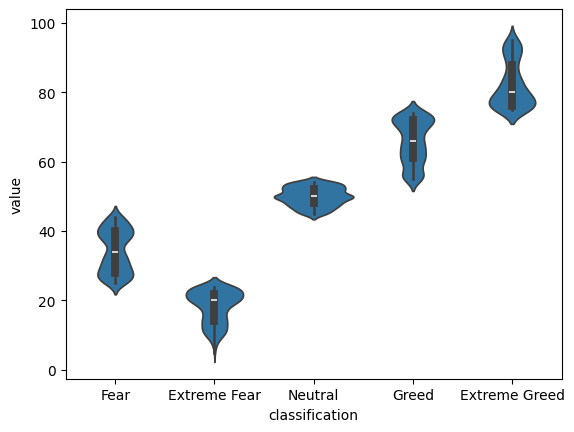

In [7]:
# get a rough idea of the value and classification distribution
sns.violinplot(data=sentiment, x='classification', y='value')

## EDA on Trading Data

In [8]:
trade_history = pd.read_csv('data/historical_data.csv')
trade_history.info()
trade_history.head()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
trade_history.describe(include=[object])

,Account,Coin,Side,Timestamp IST,Direction,Transaction Hash
count,211224,211224,211224,211224,211224,211224
unique,32,246,2,27977,12,101184
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,SELL,14-02-2025 00:31,Open Long,0x00000000000000000000000000000000000000000000...
freq,40184,68005,108528,441,49895,9032


In [10]:
trade_history.describe(include=[np.number])

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


## Pre Processing

In [11]:
def correct_date(x):
    x = x.split('-')
    x = x[::-1]
    return '-'.join(x)
sentiment['date'] = sentiment['date'].apply(correct_date)

def remove_time(x):
    return x.split(' ')[0]
trade_history['date'] = trade_history['Timestamp IST'].apply(remove_time)

## Feature Engineering

In [12]:
# Feature Engineering: Trading Hour, Day and Week
def calendar_data(x):
    x = x.split(' ')
    hour = x[1].split(':')[0]
    date = x[0]
    day_week = pd.to_datetime(x[0]).day_name()
    x = x[0].split('-')
    day_month = x[0]
    month = x[1]
    year = x[2]
    return hour,day_month,day_week,date,month,year

trade_history[
    ['hour', 'day_month', 'day_week', 'date','month','year']
] = trade_history['Timestamp IST'].apply(
    lambda x: pd.Series(calendar_data(x))
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

trade_history['Scaled PnL'] = scaler.fit_transform(trade_history[['Closed PnL']])

In [14]:
trade_history = trade_history.merge(sentiment[['date','value','classification']], on='date')

In [15]:
from pathlib import Path
import os

path = Path(os.getcwd()) / 'data' / 'processed.csv'
trade_history.to_csv(path,index=False)